# 回归树：复杂度控制与分段常数预测

本实验使用 `scikit-learn` 自带的糖尿病回归数据观察回归树的三个性质：

1. 平方误差准则下，每个叶节点输出其中训练响应的均值；
2. 树深增加时，训练 RMSE 持续下降，但交叉验证 RMSE 会在达到最小值后回升；
3. 联合调节 `max_depth` 与 `min_samples_leaf` 可以限制叶节点数量，并改善独立测试集上的 MAE、RMSE 与 $R^2$。


In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib

configure_matplotlib()

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeRegressor

plt.style.use("seaborn-v0_8-white")
RANDOM_STATE = 42
COLORS = {
    "shallow": "#59A14F",
    "tuned": "#4C78A8",
    "unrestricted": "#E45756",
}


## 1. 读取糖尿病回归数据

数据包含 $442$ 位受试者的 $10$ 个基线特征，连续响应是一年后的疾病进展指标。`scikit-learn` 已对特征作中心化与尺度处理。随机划出 $20\%$ 的样本作为独立测试集，其余样本构成开发集；测试集不参与调参。

下面同时查看体重指数 `bmi`、血清指标 `s5` 与响应的关系。散点只能显示单个特征的边际关系，回归树拟合时会同时使用全部十个特征。


,value
total samples,442.0
development samples,353.0
test samples,89.0
features,10.0
minimum response,25.0
maximum response,346.0


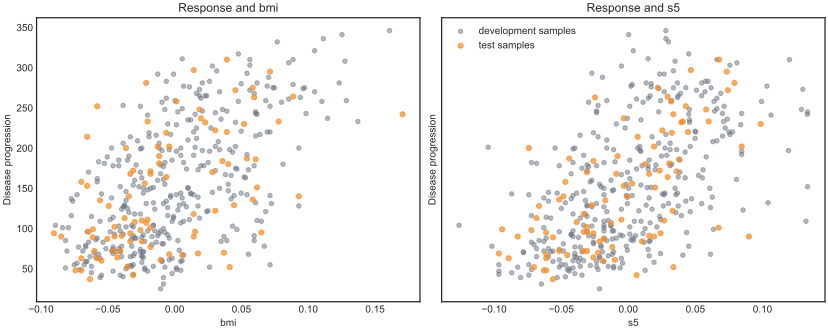

In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target.rename("disease progression")
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

regression_summary = pd.Series(
    {
        "total samples": len(X),
        "development samples": len(X_dev),
        "test samples": len(X_test),
        "features": X.shape[1],
        "minimum response": y.min(),
        "maximum response": y.max(),
    },
    name="value",
).to_frame()
display(regression_summary)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True, constrained_layout=True)
for ax, feature in zip(axes, ["bmi", "s5"]):
    ax.scatter(X_dev[feature], y_dev, s=20, alpha=0.50, color="#6B7280", label="development samples")
    ax.scatter(X_test[feature], y_test, s=27, alpha=0.72, color="#F28E2B", label="test samples")
    ax.set(title=f"Response and {feature}", xlabel=feature, ylabel="Disease progression")
axes[1].legend()
plt.show()


## 2. 不限制树生长：训练误差为零

平方误差回归树若不受限制，可以不断切分直至每个叶节点只包含一个或少数训练样本。此时模型可以近似记忆开发集，因此训练误差可能为零；这并不意味着模型已经学到了可推广的疾病进展规律。


In [3]:
def regression_metrics(model, features, response):
    prediction = model.predict(features)
    return {
        "MAE": mean_absolute_error(response, prediction),
        "RMSE": np.sqrt(mean_squared_error(response, prediction)),
        "R2": r2_score(response, prediction),
    }

unrestricted = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_dev, y_dev)
unrestricted_metrics = pd.DataFrame(
    {
        "development": regression_metrics(unrestricted, X_dev, y_dev),
        "test": regression_metrics(unrestricted, X_test, y_test),
    }
).T
unrestricted_structure = pd.Series(
    {
        "depth": unrestricted.get_depth(),
        "leaves": unrestricted.get_n_leaves(),
    },
    name="unrestricted tree",
).to_frame()
display(unrestricted_structure)
display(unrestricted_metrics.round(3))


,unrestricted tree
depth,19
leaves,346


,MAE,RMSE,R2
development,0.000,0.000,1.000
test,54.528,70.546,0.061


## 3. 树深与预测误差

固定 `min_samples_leaf=1`，用开发集上的五折交叉验证比较 `max_depth=1,2,\dots,16`。RMSE 越小越好。随着树加深，训练 RMSE 单调下降；交叉验证 RMSE 的最低点则反映欠拟合与过拟合之间的折中。


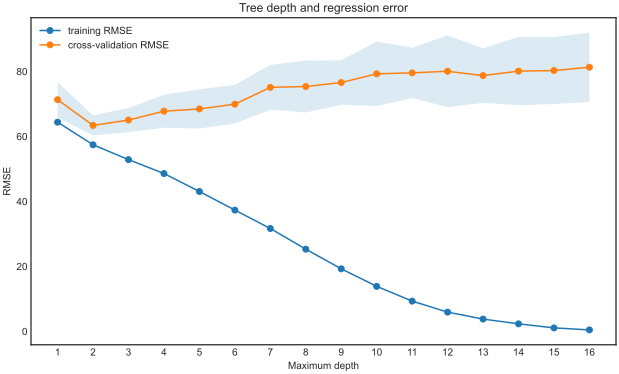

In [4]:
regression_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_rows = []
for depth in range(1, 17):
    scores = cross_validate(
        DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE),
        X_dev,
        y_dev,
        scoring="neg_root_mean_squared_error",
        cv=regression_cv,
        return_train_score=True,
        n_jobs=1,
    )
    depth_rows.append(
        {
            "max_depth": depth,
            "training RMSE": -scores["train_score"].mean(),
            "validation RMSE": -scores["test_score"].mean(),
            "validation standard deviation": scores["test_score"].std(),
        }
    )
depth_results = pd.DataFrame(depth_rows).set_index("max_depth")

fig, ax = plt.subplots(figsize=(8.6, 5.2), constrained_layout=True)
ax.plot(depth_results.index, depth_results["training RMSE"], marker="o", label="training RMSE")
ax.plot(depth_results.index, depth_results["validation RMSE"], marker="o", label="cross-validation RMSE")
ax.fill_between(
    depth_results.index,
    depth_results["validation RMSE"] - depth_results["validation standard deviation"],
    depth_results["validation RMSE"] + depth_results["validation standard deviation"],
    alpha=0.16,
)
ax.set(
    title="Tree depth and regression error",
    xlabel="Maximum depth",
    ylabel="RMSE",
    xticks=list(depth_results.index),
)
ax.legend()
plt.show()


## 4. 联合调节树深与叶节点样本量

仅限制树深仍可能在深层形成很小的叶节点。因此继续联合搜索 `max_depth` 与 `min_samples_leaf`，选择平均交叉验证 RMSE 最小的组合。`None` 表示不直接限制树深，此时叶节点样本量仍可发挥预剪枝作用。


,max_depth,min_samples_leaf,training RMSE,validation RMSE,validation standard deviation
23,4,30,55.931,63.275,2.699
41,8,30,55.931,63.275,2.699
35,6,30,55.931,63.275,2.699
29,5,30,55.931,63.275,2.699
47,None,30,55.931,63.275,2.699
6,2,1,57.425,63.392,3.089
7,2,2,57.425,63.392,3.089
8,2,5,57.425,63.392,3.089


Selected parameters: {'max_depth': 4, 'min_samples_leaf': 30}
Mean cross-validation RMSE: 63.275


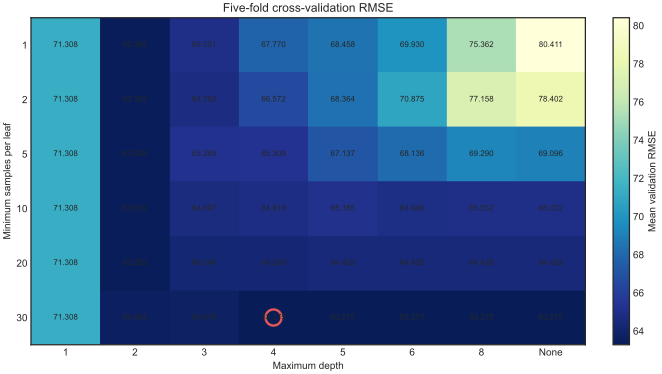

In [5]:
depth_values = [1, 2, 3, 4, 5, 6, 8, None]
leaf_values = [1, 2, 5, 10, 20, 30]
regression_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid={
        "max_depth": depth_values,
        "min_samples_leaf": leaf_values,
    },
    scoring="neg_root_mean_squared_error",
    cv=regression_cv,
    return_train_score=True,
    n_jobs=1,
)
regression_grid.fit(X_dev, y_dev)

regression_cv_results = pd.DataFrame(regression_grid.cv_results_)
regression_cv_results["depth label"] = regression_cv_results["param_max_depth"].map(
    lambda value: "None" if value is None else str(int(value))
)
regression_cv_results["training RMSE"] = -regression_cv_results["mean_train_score"]
regression_cv_results["validation RMSE"] = -regression_cv_results["mean_test_score"]
regression_cv_results["validation standard deviation"] = regression_cv_results["std_test_score"]
regression_heatmap = regression_cv_results.pivot(
    index="param_min_samples_leaf",
    columns="depth label",
    values="validation RMSE",
).reindex(index=leaf_values, columns=[str(value) for value in depth_values[:-1]] + ["None"])
top_regression_settings = (
    regression_cv_results[
        ["depth label", "param_min_samples_leaf", "training RMSE", "validation RMSE", "validation standard deviation"]
    ]
    .sort_values("validation RMSE")
    .head(8)
    .rename(columns={"depth label": "max_depth", "param_min_samples_leaf": "min_samples_leaf"})
)
display(top_regression_settings.round(3))
print(f"Selected parameters: {regression_grid.best_params_}")
print(f"Mean cross-validation RMSE: {-regression_grid.best_score_:.3f}")

fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
image = ax.imshow(regression_heatmap.to_numpy(), aspect="auto", cmap="YlGnBu_r")
for row in range(regression_heatmap.shape[0]):
    for column in range(regression_heatmap.shape[1]):
        value = regression_heatmap.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center", fontsize=8)
best_depth_label = (
    "None" if regression_grid.best_params_["max_depth"] is None
    else str(regression_grid.best_params_["max_depth"])
)
best_column = list(regression_heatmap.columns).index(best_depth_label)
best_row = list(regression_heatmap.index).index(regression_grid.best_params_["min_samples_leaf"])
ax.scatter(best_column, best_row, s=260, facecolors="none", edgecolors="#E45756", linewidths=2.4)
ax.set(
    title="Five-fold cross-validation RMSE",
    xlabel="Maximum depth",
    ylabel="Minimum samples per leaf",
    xticks=np.arange(regression_heatmap.shape[1]),
    xticklabels=regression_heatmap.columns,
    yticks=np.arange(regression_heatmap.shape[0]),
    yticklabels=regression_heatmap.index,
)
fig.colorbar(image, ax=ax, label="Mean validation RMSE")
plt.show()


## 5. 欠拟合、适度拟合与过拟合

下面把深度为 $1$ 的浅树、交叉验证选出的树和不限制复杂度的树放在一起。浅树只能将特征空间分成两个区域，容易欠拟合；不受限制的树则容易记忆开发集。预测值—真实值图中的点越接近对角线，说明预测误差越小。


depth  leaves     MAE    RMSE     R2
model        data                                             
shallow      development      1       2  54.471  65.018  0.304
             test             1       2  56.507  67.872  0.131
tuned        development      4       7  44.809  56.240  0.479
             test             4       7  44.185  55.072  0.428
unrestricted development     19     346   0.000   0.000  1.000
             test            19     346  54.528  70.546  0.061

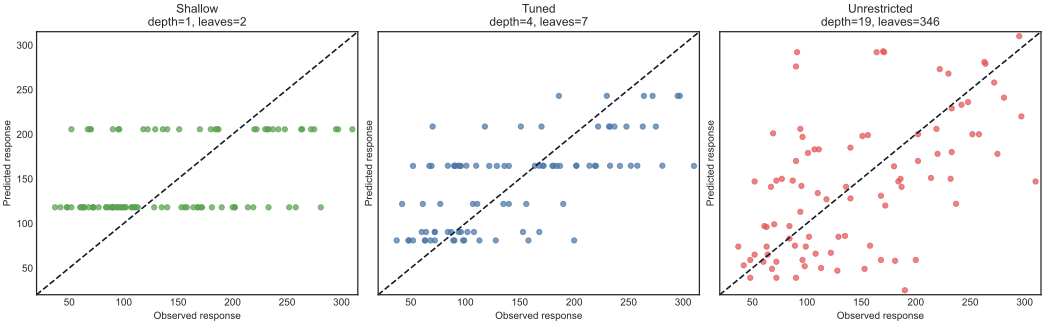

In [6]:
shallow = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE).fit(X_dev, y_dev)
tuned_regressor = regression_grid.best_estimator_
regression_models = {
    "shallow": shallow,
    "tuned": tuned_regressor,
    "unrestricted": unrestricted,
}
comparison_rows = []
for model_name, model in regression_models.items():
    for data_name, features, response in [
        ("development", X_dev, y_dev),
        ("test", X_test, y_test),
    ]:
        comparison_rows.append(
            {
                "model": model_name,
                "data": data_name,
                "depth": model.get_depth(),
                "leaves": model.get_n_leaves(),
                **regression_metrics(model, features, response),
            }
        )
regression_comparison = pd.DataFrame(comparison_rows).set_index(["model", "data"])
display(regression_comparison.round(3))

all_predictions = np.concatenate([model.predict(X_test) for model in regression_models.values()])
plot_min = min(y_test.min(), all_predictions.min()) - 5
plot_max = max(y_test.max(), all_predictions.max()) + 5
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5), sharex=True, sharey=True, constrained_layout=True)
for ax, (model_name, model) in zip(axes, regression_models.items()):
    prediction = model.predict(X_test)
    ax.scatter(y_test, prediction, s=28, alpha=0.72, color=COLORS[model_name])
    ax.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", linewidth=1.6, color="#111827")
    ax.set(
        title=f"{model_name.capitalize()}\ndepth={model.get_depth()}, leaves={model.get_n_leaves()}",
        xlabel="Observed response",
        ylabel="Predicted response",
        xlim=(plot_min, plot_max),
        ylim=(plot_min, plot_max),
    )
plt.show()


## 6. 基于不纯度下降的特征重要性

正文将特征重要性定义为各分裂节点上加权不纯度下降的归一化总和。下面列出调参后回归树对十个特征的使用情况。该得分只描述当前树的分裂结构，不表示因果效应。


,importance
bmi,0.635
s5,0.193
s6,0.105
bp,0.045
s3,0.023
age,0.000
sex,0.000
s1,0.000
s2,0.000
s4,0.000


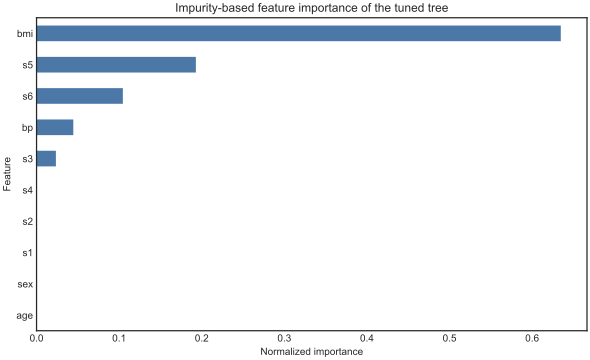

In [7]:
feature_importance = pd.Series(
    tuned_regressor.feature_importances_, index=X.columns, name="importance"
).sort_values(ascending=False)
display(feature_importance.to_frame().round(3))

fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
feature_importance.sort_values().plot.barh(ax=ax, color="#4C78A8")
ax.set(
    title="Impurity-based feature importance of the tuned tree",
    xlabel="Normalized importance",
    ylabel="Feature",
)
plt.show()


## 7. 验证叶节点的均值预测

对开发集中的每个样本，`apply` 返回其叶节点编号。将样本按该编号分组后，可以直接比较组内响应均值与树的输出。平方误差准则下二者应当相同。


In [8]:
leaf_diagnostics = pd.DataFrame(
    {
        "leaf": tuned_regressor.apply(X_dev),
        "response": y_dev,
        "tree prediction": tuned_regressor.predict(X_dev),
    }
)
leaf_summary = (
    leaf_diagnostics.groupby("leaf")
    .agg(
        samples=("response", "size"),
        response_mean=("response", "mean"),
        tree_prediction=("tree prediction", "first"),
    )
    .sort_index()
)
leaf_summary["absolute difference"] = (
    leaf_summary["response_mean"] - leaf_summary["tree_prediction"]
).abs()
display(leaf_summary.head(10).round(6))
print(f"Maximum absolute difference over all leaves: {leaf_summary['absolute difference'].max():.3e}")


,samples,response_mean,tree_prediction,absolute difference
leaf,,,,
3,49,80.877551,80.877551,0.0
5,64,121.859375,121.859375,0.0
6,39,90.333333,90.333333,0.0
7,57,164.666667,164.666667,0.0
10,49,164.469388,164.469388,0.0
11,45,208.644444,208.644444,0.0
12,50,243.000000,243.000000,0.0


Maximum absolute difference over all leaves: 0.000e+00


## 观察

不限制复杂度的树形成 $346$ 个叶节点，在开发集上的 RMSE 为 $0$、$R^2=1$，但测试 RMSE 约为 $70.546$、$R^2$ 约为 $0.061$。五折交叉验证返回 `max_depth=4`、`min_samples_leaf=30`；在 `min_samples_leaf=30` 时，所有不低于 $4$ 的深度上限得到相同结果，说明叶节点样本量已经使实际树深停在 $4$。调参后的树只有 $7$ 个叶节点，测试 MAE 约为 $44.185$、RMSE 约为 $55.072$、$R^2$ 约为 $0.428$。这说明继续降低训练误差已经是在拟合开发集中的偶然波动。

预测值—真实值图显示，深度为 $1$ 的树预测过于集中，而不限制复杂度的树在测试集上仍然十分离散。最后的叶节点核对中，调参后树的输出与节点内开发集响应均值只存在浮点舍入误差，与平方误差节点不纯度的理论结论一致。
